In [55]:
import tensorflow as tf
import numpy as np

In [56]:
def categorize_labels(label: float) -> float:
    if label < -0.15:
        return 0.0
    if label < -0.05:
        return 1.0
    if label < 0.05:
        return 2.0
    if label < 0.15:
        return 3.0
    
    return 4.0

In [57]:
data = np.loadtxt('stock_curated.csv', delimiter=',')
X = data[:252,:]
raw_Y = np.array(data[-2:-1,:])

Y = (tf.keras.utils.to_categorical(np.vectorize(categorize_labels)(raw_Y), 5)).T

In [58]:
Y.shape = (Y.shape[0], Y.shape[1])
print(Y.shape)

(5, 43164)


In [59]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(252, activation='relu', kernel_initializer="he_normal", kernel_regularizer=tf.keras.regularizers.l2(0.01), input_shape=(252,)),
    #tf.keras.layers.Dense(512, activation='tanh', kernel_initializer="he_normal", kernel_regularizer=tf.keras.regularizers.l2(0.01), input_shape=(252,)),
    #tf.keras.layers.Dense(512, activation='relu', kernel_initializer="he_normal", kernel_regularizer=tf.keras.regularizers.l2(0.01), input_shape=(512,)),
    #tf.keras.layers.Dropout(0.3),
    #tf.keras.layers.Reshape((512, 1)),
    #tf.keras.layers.Conv1D(filters=30, kernel_size=7, activation='relu', padding='same'),
    #tf.keras.layers.MaxPooling1D(pool_size=7),
    #tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(5, activation='softmax', input_shape=(252,)),
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 5)              │         1,265 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,021 (253.99 KB)

 Trainable params: 65,021 (253.99 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
train_size = 42000

X_train = X[:,:train_size].T
Y_train = Y[:,:train_size].T

X_val = X[:,train_size:].T
Y_val = Y[:,train_size:].T

print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)

(42000, 252)
(42000, 5)
(1164, 252)
(1164, 5)


In [61]:
model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=250,
                  verbose=1,
                  shuffle=True)

Epoch 1/250
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2859 - loss: 434.8673 - val_accuracy: 0.2079 - val_loss: 4.6229
Epoch 2/250
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2871 - loss: 244.3632 - val_accuracy: 0.2113 - val_loss: 4.7577
Epoch 3/250
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2884 - loss: 7.5358 - val_accuracy: 0.2113 - val_loss: 4.1146
Epoch 4/250
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2887 - loss: 5.4631 - val_accuracy: 0.2088 - val_loss: 4.2658
Epoch 5/250
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2889 - loss: 10.9633 - val_accuracy: 0.2079 - val_loss: 4.2061
Epoch 6/250
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2889 - loss: 3.9739 - val_accuracy: 0.2105 - val_loss: 4.3223
Epoch 7/250
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2893 - loss: 3.3616 - val_accuracy: 0.2070 - val_loss: 4.1921
Epoch 8/250
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2894 - loss: 3.2515 - val

KeyboardInterrupt: 

In [8]:
import matplotlib.pyplot as plt

def plot_acc_and_loss(history, title):
    plt.title("Model and Validation MAE for " + title)
    xs = list(range(1, len(history.history['accuracy']) + 1))
    plt.plot(xs, history.history['accuracy'], label="Model MAE", color="Red", marker='o')
    plt.plot(xs, history.history['val_accuracy'], label="Validation MAE", color="Blue", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.title("Model and Validation Loss for " + title)
    xs = list(range(1, len(history.history['val_loss']) + 1))
    plt.plot(xs, history.history['loss'], label="Model loss", color="Red", marker='o')
    plt.plot(xs, history.history['val_loss'], label="Validation loss", color="Blue", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()

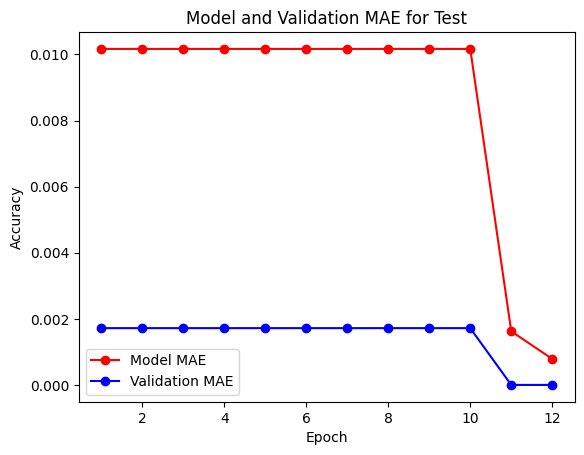

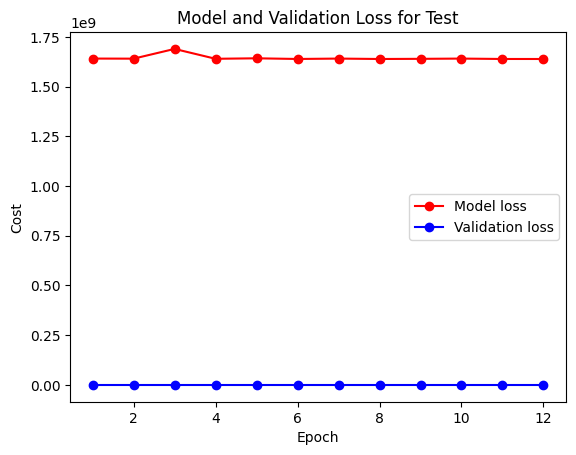

In [9]:
plot_acc_and_loss(model.history, "Test")

In [16]:
print("Prediction:", model.predict(X_train[0]))
print("Label:", Y_train[0])

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32,), dtype=float32) with name 'keras_tensor_8' and path ''. Expected shape (None, 252), but input has incompatible shape (32,)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32,), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>